# Проект: Анализ отзывов на рестораны и отели

## Задача

Прогноз оценки пользователя по тексту отзыва. Выявление эмоций.

## Источник и состав данных

### Источник:

данные из Яндекс.карт за 2023 год: https://www.kaggle.com/datasets/kyakovlev/yandex-geo-reviews-dataset-2023

### Состав данных:

Адрес организации (address)

Название организации (name_ru)

Категория, которой принадлежит организация (rubrics)

Оценка пользователя от 0 до 5 (rating)

Текст отзыва (text)

## EDA

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 11.4 MB/s eta 0:00:00


In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from catboost import CatBoostClassifier, Pool
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os
import evaluate
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
    Trainer, DataCollatorWithPadding)

pd.set_option('display.max_colwidth', None)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv('drive/MyDrive/Karpov_Courses_ITMO/geo-reviews-dataset-2023.csv')

In [ ]:
## Отбираем отели и рестораны
data = data[(data['rubrics'].isin(['Гостиница', 'Ресторан', 'Кафе', 'Быстрое питание', 'Ресторан;Кафе', 'Кафе;Ресторан',
                                 'База, дом отдыха', 'Санаторий', 'Турбаза', 'Ресторан;Бар, паб;Кафе', 'Столовая',
                                 'Бар, паб', 'Ресторан;Бар, паб', 'Быстрое питание;Кафе', 'Кафе;Быстрое питание',
                                 'Ресторан;Банкетный зал', 'Ресторан;Кафе;Банкетный зал', 'Бар, паб;Кафе;Ресторан',
                                 'Ресторан;Доставка еды и обедов', 'Бар, паб;Ресторан', 'Кофейня;Кафе',
                                 'Кафе;Бар, паб;Ресторан', 'Ресторан;Кафе;Доставка еды и обедов',
                                 'Быстрое питание;Кафе;Ресторан', 'Кафе;Бар, паб', 'Кафе;Бар, паб',
                                 'Ресторан;Доставка еды и обедов;Банкетный зал', 'Пиццерия;Быстрое питание',
                                 'Кафе;Ресторан;Доставка еды и обедов', 'Бар, паб;Кафе'])) |
            (data['rubrics'].str.contains('Ресторан')) | (data['rubrics'].str.contains('Кафе')) |
            (data['rubrics'].str.contains('Гостиница'))]

In [ ]:
data['org_type'] = ['Гостиница' if ('Гостиница' in x) | (x in ('База, дом отдыха', 'Санаторий', 'Турбаза')) else
                    'Ресторан' for x in data['rubrics']]

In [ ]:
data.head()

,address,name_ru,rating,rubrics,text,org_type
6,"Воронежская область, Богучарский район, М-4 Дон, 770-й километр",У тещи,4.0,Кафе,"Глубинка страны во всех своих проявлениях. Ассортимент столовский, интерьер, качество и цены приемлемые для средней бюджетной столовой СССР, не все чистое, все не новое... А что бы вы хотели на трассе. Поел, желудок не бастовал, значит риск был оправдан. Номер для ночлега аналогичного толка. Пластиковое окно нормально не закрылось, шторы на окне нет, только тюль. Для первого этажа - плохо. Мало ли кто заглядывает. Туалет, душ... Совок, но, повторюсь, для трассы да за 1000 руб - сойдет.\n",Ресторан
8,"Москва, 4-й Кожевнический переулок, 4",Jinju,5.0,Кафе;Кофейня,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вкуснее, чем капуч на фундучном молоке с фирменными сливками Джинжу, не пробовал ничего! Десерты тоже очень необычные. Ребята - бариста большие молодцы! \n\nЧто можно улучшить? Маловато места, с посадкой можно что-то придумать?\n",Ресторан
9,"Москва, 4-й Кожевнический переулок, 4",Jinju,4.0,Кафе;Кофейня,"Не очень удобное расположение, от метро идти мин 20 быстрым шагом через промзону. В самом кофе мест очень мало, а желающих очень много(( пирожные очень вкусные, кофе…бывает вкуснее. Второй раз именно туда на пойду.\n",Ресторан
13,"Краснодарский край, городской округ Сочи, посёлок городского типа Дагомыс, Балтийская улица, 19",Пандок,2.0,Ресторан,"Самый большой плюс это месторасположение, набережная , шикарный вид на море! Красиво, уютно, вот собственно плюсы закончились .. огорчает отношение к посетителям, официанты неприветливые, не здравствуйте вам, не до свидания . Лица недовольные, неприятные, больше не хочется смотреть на такие! Кухня тоже оставляет желать лучшего, в люле кебаб кости попадаются, шашлык из говядины сухой и невкусный. Мы на отдыхе , на позитиве , денег не жалеем, но хочется приходить туда где нам рады!!\n",Ресторан
14,"Краснодарский край, городской округ Сочи, посёлок городского типа Дагомыс, Балтийская улица, 19",Пандок,5.0,Ресторан,"Добрый день! Сегодня во второй раз посетили с дочкой ресторан, нравится меню (куриный суп-лапша, пицца 4 сыра, яблочный штрудель; сациви из курицы, облепиховый чай-то, что успели попробовать за эти 2 посещения) и особенно порадовало прекрасное обслуживание, спасибо Алле за заботу и предупредительность! Разумное соотношение цены и качества, приятная атмосфера в заведении вызывают желание снова посетить и порекомендовать это место. Спасибо, и успехов! С уважением, Оксана и Злата.\n",Ресторан


In [ ]:
## Количество отзывов в каждой категории
data.groupby('org_type')['name_ru'].count()

,name_ru
org_type,
Гостиница,51945
Ресторан,101505


In [ ]:
data.groupby(['org_type', 'rating'], as_index = False)['name_ru'].count()

,org_type,rating,name_ru
0,Гостиница,0.0,32
1,Гостиница,1.0,1889
2,Гостиница,2.0,1338
3,Гостиница,3.0,3046
4,Гостиница,4.0,7021
5,Гостиница,5.0,38619
6,Ресторан,0.0,38
7,Ресторан,1.0,6806
8,Ресторан,2.0,3422
9,Ресторан,3.0,5644


In [ ]:
## Средняя оценка
data.groupby(['org_type'], as_index = False)['rating'].mean()

,org_type,rating
0,Гостиница,4.521898
1,Ресторан,4.422294


In [ ]:
## Мода
data.groupby(['org_type'], as_index=False)['rating'].apply(lambda x: x.mode().iloc[0])

,org_type,rating
0,Гостиница,5.0
1,Ресторан,5.0


In [ ]:
data[data['rating'] == 0]

,address,name_ru,rating,rubrics,text,org_type
1907,"Республика Карелия, Суоярви, улица Шельшакова, 1",Гостиница Карелия,0.0,Гостиница,"Гостиница расположенна удобно, если отремонтируют номера, будет супер\n",Гостиница
3584,"Краснодарский край, Анапа, улица Пушкина, 30",Кубань,0.0,Санаторий,"Нет растительного масла для салата, нет зубочисток на столах. Номер требует ремонта: шкаф разваливается, дверь не закрывалась вызывали плотника, туалетная комната стеклянная полочка оторвана вызывали плотника починил, телевизор старый пульт разбит и не работает посуду для чая не не выдают (тарелки,ложки, кружки) даже за отдельную плату\n",Гостиница
3615,"Краснодарский край, Туапсинский район, Новомихайловское городское поселение, село Ольгинка, Черноморская улица, 3",Счастливый Хотей,0.0,Гостиница,"Все довольны, и взрослые и дети.\nВкусная еда.\nБанька и бассейны всё замечательно.\nЕздием к вам уже 4 год и привозим к вам ещё новых гостей(делаем вам рекламу) 😁👍номера комфортные, чистые и уютные.\n",Гостиница
8232,"Краснодарский край, Анапа, Виноградная улица, 14Б",Кайт,0.0,Гостиница,"Отличный гостевой дом. Тихо, чисто, удобные номера, есть холодильник, сплит-система, душ и туалет.До моря 3 минуты, по дороге много столовых, рядом магазины Магнит и Пятерочка. Очень хорошие и доброжелательные хозяева.Рекомендую этот дом.\n",Гостиница
15554,"Нижний Новгород, улица Пискунова, 40, корп. 3",Джани ресторани,0.0,Ресторан;Доставка еды и обедов;Кейтеринг,"Вкусно. Много народу, столик стоит бронировать заранее. Завтраки отличные. Хрустящий баклажан, салат Цезарь, хинкали, всё на высоте. Лимонад - супер. Цены тоже, вполне московские. Что-то отметить - отлично. Рутинно - дороговато\n",Ресторан
...,...,...,...,...,...,...
473438,"Ленинградская область, Выборг, проспект Ленина, 9",Солнечный день,0.0,Доставка еды и обедов;Кафе;Столовая,"Готовьтесь к запаху едой на одежде)) Приятно пахнет ядой. Но, уже в начале посещения, наступает разочарование - подносы...жирные, аж из рук уезжают. Это говорит о многом. Экономия салфеток. На столах их нет. Столовые приборы находятся рядом с кассой. То есть все, что есть на верхней одежде, деньгах, руках-всё на них родимых. Столы чистые, без запаха. Есть туалеты (в них не заходила). Отдельно расположена раковина в коридоре, по пути в туалеты, где можно вымыть руки. Мыло есть, раковина чистая. Ну, а теперь о главном, о еде. Мы пробовали рис, тефтели, куриные купаты, компот, круассан, горячий напиток для здоровья(напоминает чай). Хотели взять макароны, но они были такие уставшие, слипшиеся, и уже в перемешку с соусом, что говорит о том, что они не свежие. Рис очень вкусный. Рассыпчатый, не не доваренный, не переваренный. Тефтели очень нежные, вкусные. Но, вот куриные купаты были сухими, с кисловатым вкусом (не стали их есть, только попробовали). Компот вкусный, но ледяной,тк стаканы хранятся в холодильнике. Не спорю, может так и должен храниться, но на улице зима, хоть и погода осенняя, но все равно прохладно. Круассан сухова. Нет той нежности и тянутости, как должно быть. Девушка, которая накладывает еду, тут же берет деньги в руки. Всё это без перчаток. Увы, но с таким количеством ""Но"", я не могу рекомендовать это заведение. И, открылись вроде бы недавно, а уже такой низкий уровень. Очень хочется верить, что услышат и исправятся.\n",Ресторан
475662,"Республика Дагестан, Дербент, улица Батманова, 54",Рояль,0.0,Гостиница,"Отдыхаем сейчас (июль 2023) . Всё нравится! Номер у нас Семейный на четверых, по размерам средний, есть большая кровать, и две кушетки- умещаемся без проблем. В номерах чисто, аккуратно и красиво. Убираются каждый день, каждые 3 дня меняют бельё. Есть два тёплых бассейна, дети вечером резвятся вовсю. Завтраки включены в стоимость, к ним претензий нет никаких. Обед и ужин- легко, но скуден выбор и субъективно дороговато. Парковка на территории, но мы не загоняли машину- снаружи куча камер, и мы в любой момент можем уехать, куда заблагорассудится. Минуса два: дороговато на фоне остальных и море возле отеля не

Видим, что rating = 0 содержит в том числе положителные отзывы. Уберем их из обучения.

In [ ]:
data[(data['rating'] >= 1) & (data['rating'] <= 2)][['text', 'rating']].head()

,text,rating
13,"Самый большой плюс это месторасположение, набережная , шикарный вид на море! Красиво, уютно, вот собственно плюсы закончились .. огорчает отношение к посетителям, официанты неприветливые, не здравствуйте вам, не до свидания . Лица недовольные, неприятные, больше не хочется смотреть на такие! Кухня тоже оставляет желать лучшего, в люле кебаб кости попадаются, шашлык из говядины сухой и невкусный. Мы на отдыхе , на позитиве , денег не жалеем, но хочется приходить туда где нам рады!!\n",2.0
18,"1. Доставка очень долгая, на рекламной брошюре написано от 500 р доставка бесплатно, а по факту заплатили 100 р за доставку. Чек был на 577р\n2. Долго плевались от нагара который был на сковородке (подноса) с мясом, хруст на зубах не приятен. \nИспорченное мнение от вашего заведения. \n",1.0
76,"Заказали фо-бо и том-ям\nКороче больше не приду к ним. \nВ том яме заявлены черри их нет в том ям идет кокосовое молоко его нет. \nФо-бо воняет чем то не приятно. В фо-бо нет ростков пшеницы, нет кинзы. Спрашивается почему цена как за целое блюдо, но в блюдах не хватает компонентов. Не позортесь. Смените название, на ""собрали из того что было "" Позор руководству производства. \n",1.0
94,"Кроме того, что место красивое и необычное, плюсов нет. Были 1 июня.\nАренда 2500 час, но это просто за иглу. 1000 пробковый сбор, хотя по умолчанию в заведении нет напитков и еды, все приносишь с собой. Сервировка стола платная, при этом сюда входит тарелка,стакан и приборы (Рюмка или бокал за отдельную плату). Посуда самая дешевая, при этом за 1 разбитую единицу штраф-1000. Стол в иглу, которое досталось нам был не закреплен. Т.е крышка и подножья стола существовали отдельно, каждый раз стол болтался, и не разбить там посуду было сложно. Музыкальная колонка тоже попалась «уставшая» громкость не регулировалась. Заказ был на 3 часа+ 1 в подарок, при этом девушка-администратор, насчитала за 4 часа. Прям настаивать пришлось, чтобы сделать перерасчет. Ощущение, что за все пытаются сбить деньги, при этом сервис на 2 балла.\n",2.0
152,"Зашли единожды в это кафе. Заказали с собой еду. Простите ,но так себе. Картошка фри та же самая никакая. В фаст-фуд кортах и то лучше в разы. Паста тоже ( Будто макароны по-флоцки). Вдобавок дома вскрыв коробки обнаружили, что вместо двух разных пицц нам положили две одинаковых. 😖Пиццей в принципе это можно назвать с натяжкой.Будто дешевой ветчины сверху накидали. Вся еда пресная. \nСамое отвратительно место на районе. Не советую к посещению. \nП.с. На негативные отзывы ставят негативные лайки явно не посетители этого «кафе». \n",1.0


Видим, что с низкими оценками у нас негативные отзывы.

Для оценки качества разметки прогоним отзывы через модель, которая выделит отрицательные, положительные отзывы и посмотрим, на сколько они соответствуют оценкам.

In [ ]:
print("Загрузка модели...")
classifier = pipeline(
    task="text-classification",
    model="cointegrated/rubert-tiny-sentiment-balanced",
    device=0 if torch.cuda.is_available() else -1
)


Загрузка модели...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/884 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/377 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/241k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/468k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
label_mapping = {
    'LABEL_0': 'neutral',
    'LABEL_1': 'positive',
    'LABEL_2': 'negative'
}


def process_in_batches(texts, batch_size=64):
    results_labels = []
    results_scores = []


    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        predictions = classifier(batch, truncation=True, max_length=512)

        for pred in predictions:
            results_labels.append(label_mapping.get(pred['label'], pred['label']))
            results_scores.append(round(pred['score'], 3))

    return results_labels, results_scores

In [ ]:
texts_list = data['text'].tolist()
labels, scores = process_in_batches(texts_list, batch_size=64)

  0%|          | 0/2402 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
data['sentiment'] = labels
data['sentiment_confidence'] = scores

In [ ]:
data.groupby(['rating', 'sentiment'])['name_ru'].count()

rating  sentiment
0.0     negative          3
        neutral           7
        positive         60
1.0     negative       6522
        neutral        1585
        positive        588
2.0     negative       2524
        neutral        1553
        positive        683
3.0     negative       2967
        neutral        3450
        positive       2273
4.0     negative       2174
        neutral        4714
        positive       9801
5.0     negative       6314
        neutral        7906
        positive     100326
Name: name_ru, dtype: int64

In [ ]:
data[(data['rating']==1) & (data['sentiment']=='positive')]['text'].head()

,text
1039,"Извините,обычно не пишу отзывы о заведениях,где питаюсь,но здесь не могу промолчать. Молодому человеку,который обслуживал наш стол,большое спасибо,парень действительно молодец,но еда отвратительна,честно,при всем желании найти плюсы и сказать комплименты-не могу. К сожалению,даже не веранде увидели таракана,что не красит абсолютно никаким образом. Надеюсь,что это действительно поможет Вам становится лучше!\n"
1711,"Приветливый и вежливый персонал и вкусная еда. но ресторан теряет 50% клиентов в очереди из-за того, что ожидание составляет 10-20 минут только в ОЧЕРЕДИ, а уже ожидание заказа 10-15 минут, что для людей, которые приходят сюда на свой рабочий обед критично, это не стоит затраченного времени\n"
2212,"Не умеют готовить еду. Надо им куда то сходить, поесть шашлык , впрочем, в любой другой ресторан кавказской кухни. Помидоры, да, вкусные. Хорошо, что не они их не готовят.\n"
3066,"Пришли туда завтракать, так как очень рекомендовал друг. Сказали могу сесть за любой стол, так как все были свободны. Сел за стол, несмотрятна то что стол сервирован, на столу много хлебных крошек. Принесли блюдо, взял вилку - а она грязная (прям засохшая еда от прошлого посетителя была). Другу принесли суп, он там волос выловил ... больше туда никогда не придём!\n"
4949,"Позвонили забронировать столик, покурить кальян компанией, девушка администратор сказала, что столик есть и все отлично)\nМы собрались с ребятами, ехали из Калининграда, путь не ближний, 50 км)\nВ итоге приехали и ребята на баре развернули нас со словами «все столики заняты и у нас закончился табак» - настроение на вечер было нам обеспечено, уехли из Светлогорска с ужасным настроением. Спасибо, отличный сервис!\n\n"


Видим, что в таких случаях отзывы, как правило, отрицательные, есть сарказмы.
Можем использовать такие отзывы для разметки сарказмов.

In [ ]:
data[(data['rating']==5) & (data['sentiment']=='negative')]['text'].head()

,text
161,"Уютно, чисто, комфортно. \nПожелание на завтрак поставить зерновую кофемашину, пить растворимый как то уже не привычно.\n"
182,"Нам очень понравитось данное заведение, ходили парой попробовать напиток чай с тапиокой, но не обошлось без покупки вкусняшек) взяли корн дог и ролл из рисовой бумаги и креветок. Безумно вкусно, что напиток, что еда. Очень уютная и приятная атмосфера. Месторасположение тоже огонь, прям в центре на Вайнера. Цены приемлемые. Хозяева совсем приятные, доброжелательные люди. \nПосле посещения в голове остались мысли вернуться туда снова и попробовать, что то новенькое. \n"
280,"Приятное кафе, где можно вкусно позавтракать, выпить кофе и не только. \nОчень проработанный интерьер, который только добавляет плюсов заведению. \nТакже есть выбор красивых (про вкусных не знаю, не пробовала) десертов\nЕсли думаете завтракать тут или нет, то однозначно советую!\n"
296,"Очень вкусно и сытно, рекомендую, быстрая подача\n"
342,"Уютное место в центре города. Еда вкусная. Быстро все принесли. Ресторан маленький, видимо поэтому официанты при входе спрашивают всех был ли забронирован стол. Если нет, то сажают, но ограничивают по времени\n"


В примерах с негативным окрасом и высокой оценкой отзывы положительные. В целом, оценки соответствуют разметке по модели тональности. Исключения - 4% отзывов. Для повышения точности разметки по ним можно просмотреть тексты отзывов вручную.

Для разметки сарказмов планируется вручную разметить небольшую выборку с положительной тональностью и низкой оценкой и на ней обучить модель.

Сохраним файл с данными для проведения разметки.

In [ ]:
data.to_csv('rewies.csv', index = False)

# Оценки

## Baseline по оценкам и EDA

Так как данных достаточно, данные, требующие ручной разметки, исключим из рассмотрения.

В качестве baseline выберем прогноз самой часто встречающейся оценки, альтернативный baseline - полученный с помощью Tf-Idf и логистической регрессии.

Метрики: macro F1-score, weighted F1-score.

In [5]:
data = pd.read_csv('drive/MyDrive/Karpov_Courses_ITMO/rewies.csv')

In [6]:
data_score = data[(data['rating'] >= 1) &
                  (((data['rating'] >=4)  & (data['sentiment'].isin(['neutral', 'positive']))) |
                  ((data['rating'].isin ([3, 2])) & (data['sentiment'].isin(['neutral', 'negative']))) |
                  ((data['rating'] ==1) & (data['sentiment'] == 'negative')))].reset_index(drop = True)

In [9]:
data_score.shape

(139974, 8)

Посмотрим, есть ли пустые отзывы.

In [8]:
empty_count = data_score['text'].isna().sum() + (data_score['text'].astype(str).str.strip() == '').sum()

In [9]:
empty_count

np.int64(0)

Их нет. Вычислим минимальную длину отзыва.

In [11]:
data_score['text'].astype(str).str.len().min()

8

In [12]:
 data_score[data_score['text'].astype(str).str.len() == 8]

,address,name_ru,rating,rubrics,text,org_type,sentiment,sentiment_confidence
133147,"Москва, Мясницкая улица, 9/2",Ocean Basket,5.0,Ресторан,Вполне!\n,Ресторан,neutral,0.687
136713,"Москва, Электродная улица, 2с32",Моремания,5.0,Ресторан;Кафе,Класс! \n,Ресторан,positive,0.951


In [13]:
 data_score[data_score['text'].astype(str).str.len() < 20]['text'].count()

np.int64(138)

Видим, что короткие отзывы присутствуют в небольшом количестве. Посмотрим распределение по оценкам.

In [ ]:
data_score.groupby('rating', as_index = False)['text'].count()

,rating,text
0,1.0,6530
1,2.0,4087
2,3.0,6425
3,4.0,14538
4,5.0,108394


In [ ]:
(data_score['rating'].value_counts(normalize=True) * 100).reset_index().sort_values(by = 'rating')

,rating,proportion
2,1.0,4.665152
4,2.0,2.919828
3,3.0,4.590138
1,4.0,10.386215
0,5.0,77.438667


Выборка является сильно несбалансированной и смещенной в сторону оценок 5 (77%). Учтем это в дальнейшем.

## Разделение на обучающую, валидационную и тестовую выборки

Так как наш датасет содержит отзывы в привязке к компании и имеет дисбаланс классов, разбиение на train/valid/test будем проводить с учетом стратификации и чтобы данные по одной компании содержались только внутри одной выборки.

In [77]:
data_score['org_id'] = data_score['name_ru'].astype(str) + "_" + data_score['address'].astype(str)

X = data_score.drop(columns=['rating'])
y = data_score['rating'].astype(int)
groups = data_score['org_id']

strat_gr_kfold_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=67)
train_val_idx, test_idx = next(strat_gr_kfold_test.split(X, y, groups))

# Тестовая выборка для провери качества моделей - одна для всех моделей
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

# Выборка для обучения и валидации - 80%
X_train_val, y_train_val = X.iloc[train_val_idx], y.iloc[train_val_idx]
groups_train_val = groups.iloc[train_val_idx]

# Выделяем валидационную выборку
strat_gr_kfold_val = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
train_idx, val_idx = next(strat_gr_kfold_val.split(X_train_val, y_train_val, groups_train_val))

# Выборки исключительно для поиска гиперпараметров
X_train, y_train = X_train_val.iloc[train_idx], y_train_val.iloc[train_idx]
X_val, y_val = X_train_val.iloc[val_idx], y_train_val.iloc[val_idx]


Проверим соотношение классов для каждой выборки.

In [8]:
splits = {
    "Исходный датасет": y,
    "Тest": y_test,
    "Train+Val": y_train_val,
    "Train": y_train,
    "Val": y_val
}

report_data = []
for name, y_split in splits.items():
    total = len(y_split)
    percents = (y_split.value_counts(normalize=True) * 100).round(2).to_dict()

    row = {"Выборка": name, "Всего отзывов": total}
    for rating in [1.0, 2.0, 3.0, 4.0, 5.0]:
        row[f"{rating}, %"] = percents.get(rating, 0.0)

    report_data.append(row)

df_splits_report = pd.DataFrame(report_data).set_index("Выборка")

df_splits_report

,Всего отзывов,"1.0, %","2.0, %","3.0, %","4.0, %","5.0, %"
Выборка,,,,,,
Исходный датасет,139974,4.67,2.92,4.59,10.39,77.44
Тest,27830,4.55,2.99,4.54,10.38,77.54
Train+Val,112144,4.69,2.90,4.60,10.39,77.41
Train,83812,4.75,2.89,4.61,10.37,77.38
Val,28332,4.53,2.94,4.58,10.43,77.52


## Baseline 1: мода 5.0

In [34]:
baseline_1_preds = np.full(shape=len(y_test), fill_value=5.0)

# 1. Вычисление Macro-F1
macro_f1 = f1_score(y_test, baseline_1_preds, average="macro", zero_division=0)
print(f"Macro-F1 Score: {macro_f1:.4f}")

# 2. Вычисление Weighted-F1
weighted_f1 = f1_score(y_test, baseline_1_preds,  average="weighted", zero_division=0)
print(f"Weighted-F1 Score: {weighted_f1:.4f}")

print(classification_report(y_test, baseline_1_preds, zero_division=0))

Macro-F1 Score: 0.1747
Weighted-F1 Score: 0.6773
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      1266
           2       0.00      0.00      0.00       832
           3       0.00      0.00      0.00      1264
           4       0.00      0.00      0.00      2889
           5       0.78      1.00      0.87     21579

    accuracy                           0.78     27830
   macro avg       0.16      0.20      0.17     27830
weighted avg       0.60      0.78      0.68     27830



Видим, что выбор моды в качестве baseline приводит к тому, что взвешенный F1-score 0.68, а macro F1-score хорошо работает только для оценок 5, поэтому очень низкий.

Попробуем улучшить baseline с помощью TF-Idf без подбора парметров.

In [35]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2)

X_train_val_vectors = vectorizer.fit_transform(X_train_val['text'])
X_test_vectors = vectorizer.transform(X_test['text'])

In [36]:
baseline_model = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42, n_jobs=-1)
baseline_model.fit(X_train_val_vectors, y_train_val)

y_pred = baseline_model.predict(X_test_vectors)

In [37]:
print(f"\nBaseline 2 Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

print(f"Baseline 2 Weighted-F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print(classification_report(y_test, y_pred))


Baseline 2 Macro-F1: 0.5425
Baseline 2 Weighted-F1: 0.8117
              precision    recall  f1-score   support

           1       0.64      0.71      0.67      1266
           2       0.27      0.28      0.27       832
           3       0.34      0.42      0.38      1264
           4       0.38      0.63      0.48      2889
           5       0.97      0.86      0.91     21579

    accuracy                           0.79     27830
   macro avg       0.52      0.58      0.54     27830
weighted avg       0.84      0.79      0.81     27830



Видим, что Macro F1-score заметно улучшился и стал 0.54, weighted F1-score также вырос: 0.81 vs 0.68.
По F1-score модель западает на двойках.

Попробуем обучить Catboost без настройки гиперпараметров.

In [62]:
X_train_val_cb = X_train_val[['text']].reset_index(drop=True)
X_test_cb = X_test[['text']].reset_index(drop=True)
y_train_val_cb = y_train_val.reset_index(drop=True)
y_test_cb = y_test.reset_index(drop=True)
y_train_val_cb = y_train_val_cb - 1
y_test_cb = y_test_cb - 1

train_val_pool = Pool(data=X_train_val_cb, label=y_train_val_cb, text_features=["text"])
test_pool = Pool(data=X_test_cb, label=y_test_cb, text_features=["text"])

In [63]:
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.08,
    task_type="GPU",
    auto_class_weights="Balanced",
    eval_metric="TotalF1:average=Macro",
   # early_stopping_rounds=100,
    verbose=False,
    random_seed=42)

In [64]:
model.fit(train_val_pool)

CatBoostClassifier(auto_class_weights='Balanced', eval_metric='TotalF1:average=Macro', iterations=1500, learning_rate=0.08, random_seed=42, task_type='GPU', verbose=False)

In [65]:
y_pred = model.predict(X_test_cb)
y_pred = np.squeeze(y_pred)

print(f"\n CatBoost Macro-F1: {f1_score(y_test_cb, y_pred, average='macro'):.4f}")

print( f"Итоговый CatBoost Weighted-F1: {f1_score(y_test_cb, y_pred, average='weighted'):.4f}")

print(classification_report(y_test_cb+1, y_pred+1))



 CatBoost Macro-F1: 0.5292
Итоговый CatBoost Weighted-F1: 0.7882
              precision    recall  f1-score   support

           1       0.61      0.74      0.67      1266
           2       0.30      0.27      0.29       832
           3       0.31      0.45      0.37      1264
           4       0.33      0.64      0.43      2889
           5       0.97      0.81      0.89     21579

    accuracy                           0.76     27830
   macro avg       0.51      0.58      0.53     27830
weighted avg       0.84      0.76      0.79     27830



Видим, что качество не улучшилось относительно TF-Idf + логистическая регрессия, поэтому попробуем усложнить их.

In [38]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=100000,
    min_df=2)

In [39]:
X_train_vectors = vectorizer.fit_transform(X_train['text'])
X_val_vectors = vectorizer.transform(X_val['text'])

In [40]:
best_macro_f1 = 0
best_c = 1.0

for c_param in [0.1, 0.5, 1.0, 5.0, 10.0]:
    model = LogisticRegression(
        C=c_param,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_vectors, y_train)

    preds_val = model.predict(X_val_vectors)
    current_f1 = f1_score(y_val, preds_val, average="macro", zero_division=0)

    if current_f1 > best_macro_f1:
        best_macro_f1 = current_f1
        best_c = c_param

print(f"Best C: {best_c} (Macro F1 = {best_macro_f1:.4f})")

Best C: 5.0 (Macro F1 = 0.5491)


In [41]:
final_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=100000, min_df=2)
X_train_val_vectors = final_vectorizer.fit_transform(X_train_val['text'])
X_test_vectors = final_vectorizer.transform(X_test['text'])

final_baseline = LogisticRegression(
    C=best_c,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

final_baseline.fit(X_train_val_vectors, y_train_val)
y_pred = final_baseline.predict(X_test_vectors)

In [42]:
print(f"LogReg Model-2 Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

print(f"LogReg Model-2 Weighted-F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print(classification_report(y_test, y_pred))

LogReg Model-2 Macro-F1: 0.5494
LogReg Model-2 Weighted-F1: 0.8266
              precision    recall  f1-score   support

           1       0.65      0.72      0.68      1266
           2       0.28      0.25      0.26       832
           3       0.36      0.40      0.38      1264
           4       0.42      0.58      0.49      2889
           5       0.96      0.90      0.93     21579

    accuracy                           0.82     27830
   macro avg       0.54      0.57      0.55     27830
weighted avg       0.84      0.82      0.83     27830



Для такой конфигурации получили самое высокое качество.

Попробуем еще подобрать гиперпараметры для CatBoost.

In [73]:
X_train_cb = X_train[['text']].reset_index(drop=True)
X_val_cb = X_val[['text']].reset_index(drop=True)
X_test_cb = X_test[['text']].reset_index(drop=True)
y_train_cb = y_train.reset_index(drop=True)
y_val_cb = y_val.reset_index(drop=True)
y_test_cb = y_test.reset_index(drop=True)
y_train_cb = y_train_cb - 1
y_val_cb = y_val_cb - 1
y_test_cb = y_test_cb - 1

train_pool_search = Pool(data=X_train_cb, label=y_train_cb, text_features=["text"])
val_pool_search = Pool(data=X_val_cb, label=y_val_cb, text_features=['text'])
test_pool = Pool(data=X_test_cb, label=y_test_cb, text_features=["text"])


In [74]:
best_score = float('inf')
best_params = {}
best_score = 0

for depth in [4, 6]:
    for lr in [0.03, 0.06, 0.1]:
        model = CatBoostClassifier(
            iterations=1200,
            learning_rate=lr,
            task_type="GPU",
            auto_class_weights="Balanced",
            eval_metric="TotalF1:average=Macro",
            random_seed=42,
            verbose=False,
            depth=depth,
            l2_leaf_reg=3
        )

        model.fit(train_pool_search, eval_set=val_pool_search, early_stopping_rounds=30)

        current_score = model.get_best_score()['validation']['TotalF1:average=Macro']

        if current_score > best_score:
            best_score = current_score
            best_params = {"depth": depth, "learning_rate": lr}

print(best_params)

{'depth': 4, 'learning_rate': 0.03}


In [79]:
X_train_val_cb = X_train_val[['text']].reset_index(drop=True)
y_train_val_cb = y_train_val.reset_index(drop=True)
y_train_val_cb = y_train_val_cb - 1
train_val_pool_search = Pool(data=X_train_val_cb, label=y_train_val_cb, text_features=["text"])

In [80]:
final_model = CatBoostClassifier(
    iterations=1200,
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=3,
    task_type="GPU",
    auto_class_weights="Balanced",
    eval_metric="TotalF1:average=Macro",
   # early_stopping_rounds=100,
    random_seed=42,
    verbose=False
)


final_model.fit(train_val_pool_search)

y_pred = final_model.predict(test_pool)
y_pred = np.squeeze(y_pred)

print(f"\n CatBoost hyperparameters Macro-F1: {f1_score(y_test, y_pred+1, average='macro'):.4f}"
)
print(f"CatBoost hyperparameters Weighted-F1: {f1_score(y_test, y_pred+1, average='weighted'):.4f}"
)

print(classification_report(y_test, y_pred+1))


 CatBoost hyperparameters Macro-F1: 0.5234
CatBoost hyperparameters Weighted-F1: 0.7824
              precision    recall  f1-score   support

           1       0.60      0.75      0.67      1266
           2       0.31      0.29      0.30       832
           3       0.29      0.45      0.35      1264
           4       0.32      0.61      0.42      2889
           5       0.97      0.81      0.88     21579

    accuracy                           0.75     27830
   macro avg       0.50      0.58      0.52     27830
weighted avg       0.84      0.75      0.78     27830



Результат не лучше.
Попробуем также обучить Bert.

### Обучение RuBert(основная модель)

In [82]:
raw_datasets = DatasetDict({
    'train': Dataset.from_pandas(pd.DataFrame({'text': X_train['text'].values, 'label': (y_train - 1).values})),
    'validation': Dataset.from_pandas(pd.DataFrame({'text': X_val['text'].values, 'label': (y_val - 1).values})),
    'test': Dataset.from_pandas(pd.DataFrame({'text': X_test['text'].values, 'label': (y_test - 1).values}))
})


MODEL_NAME = "cointegrated/rubert-base-cased-nli-threeway"
NUM_LABELS = 5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=256)

tokenized_datasets = raw_datasets.map(preprocess_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    ignore_mismatched_sizes=True
)


clf_metrics = evaluate.combine(["accuracy", "f1"])

from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    f1_macro = f1_score(labels, predictions, average="macro", zero_division=0)
    f1_weighted = f1_score(labels, predictions, average="weighted", zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted
    }

training_args = TrainingArguments(
    output_dir="./rubert_imbalanced_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


trainer.train()

test_results = trainer.evaluate(tokenized_datasets['test'])


print(f"Bert Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Bert F1-Macro: {test_results['eval_f1_macro']:.4f}")
print(f"Bert F1-Weighted: {test_results['eval_f1_weighted']:.4f}")



config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/545 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.62M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,F1 Weighted
0.219734,0.401281,3,0.864068,0.618755,0.861968


Bert Accuracy: 0.8641
Bert F1-Macro: 0.6188
Bert F1-Weighted: 0.8620


In [83]:
trainer.save_model("drive/MyDrive/Karpov_Courses_ITMO/best_rubert_model")
tokenizer.save_pretrained("drive/MyDrive/Karpov_Courses_ITMO/best_rubert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('drive/MyDrive/Karpov_Courses_ITMO/best_rubert_model/tokenizer_config.json',
 'drive/MyDrive/Karpov_Courses_ITMO/best_rubert_model/tokenizer.json')

Получили лучший результат F1-Macro 0.62, F1-Weighted 0.86.

### Постробработка предсказаний и анализ качества модели

In [84]:
from sklearn.metrics import confusion_matrix

test_output = trainer.predict(tokenized_datasets['test'])
logits = test_output.predictions
predicted_indices = np.argmax(logits, axis=-1)
y_pred_final = predicted_indices + 1
y_true_final = test_output.label_ids + 1


Построим classification report.

In [85]:
print(
    classification_report(
        y_true_final,
        y_pred_final,
        labels=[1, 2, 3, 4, 5],
        zero_division=0,
    )
)


              precision    recall  f1-score   support

           1       0.76      0.73      0.75      1266
           2       0.38      0.35      0.36       832
           3       0.48      0.48      0.48      1264
           4       0.57      0.54      0.55      2889
           5       0.95      0.96      0.95     21579

    accuracy                           0.86     27830
   macro avg       0.63      0.61      0.62     27830
weighted avg       0.86      0.86      0.86     27830



Видим, что модель хорошо определяет очень позитивные и очень негативные оценки. Посмотрим на матрицу ошибок.

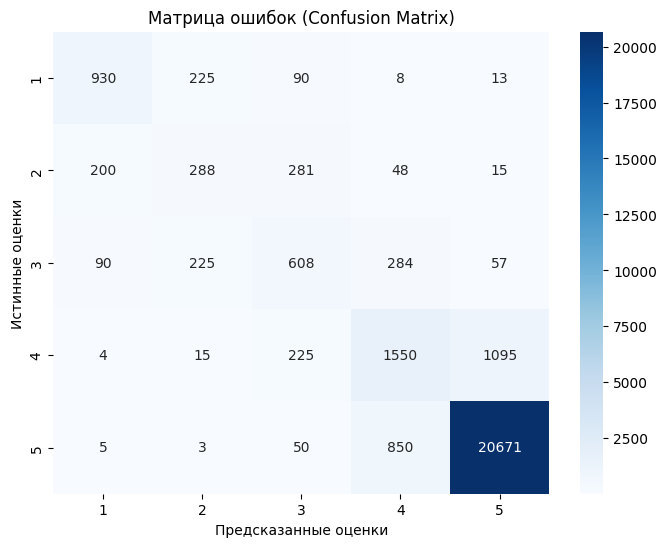

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_final, y_pred_final, labels=[1, 2, 3, 4, 5])

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['1', '2', '3', '4', '5'],
    yticklabels=['1', '2', '3', '4', '5'],
)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинные оценки')
plt.xlabel('Предсказанные оценки')
plt.show()

Видим, что ошибки чаще всего сосредоточены на уровне предсказания +1 либо -1 от реального. 1.4% от выборки - предсказания, отличающиеся от факта на 2 и более, то есть результат довольно неплохой.

Если говорить про оценку "два", то когда мы вместо 2 предсказываем 1, то это тоже можно отнести к категории негативных отзывов, такая ошибка не является критичной для бизнеса. В случае, когда для двойки предсказывается 3 - хуже, так как можно пропустить негативный отзыв, посчитав его нейтральным. От общего количества двоек 41% предсказываются как нейтральные/положительные. В целом, для 20.6% негативных оценок модель предсказывает нейтральную/положительную оценку, то есть мы детектирует 78.3% отзывов с 1-2 как негативные, что достаточно хороший результат.

Для дальнейшего улучшения качества модели и повышения recall для негативных отзывов можно попробовать следующее:

1. Модифицировать функцию потерь (сильнее штрафовать за ошибки на негативных отзывах с помощью добавления весов классов или с помощью функции потерь Focal Loss).

2. Провести oversampling негативных и нейтральных отзывов с помощью создания синтетических отзывов для оценок 1-3 (NLP-аугментация)

3. Сместить границу предсказания 3, относя к негативному классу в случае сомнения: уверенность модели (вероятность softmax) ниже порога.






### Распознавание эмоций

In [ ]:
data = pd.read_csv('reviewes.csv')

In [ ]:
## Сделаем разметку эмоций
classifier = pipeline(
    task="text-classification",
    model="seara/rubert-tiny2-russian-emotion-detection-cedr",
    device=0 if torch.cuda.is_available() else -1
)

label_mapping = {
    'no_emotion': 'нейтрально',
    'joy': 'радость',
    'sadness': 'грусть',
    'anger': 'злость',
    'surprise': 'удивление',
    'fear': 'страх'
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/117M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/410 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
def process_emotions_in_batches(texts, batch_size=64):
    results_labels = []
    results_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        predictions = classifier(batch, truncation=True, max_length=512)

        for pred in predictions:
            results_labels.append(label_mapping.get(pred['label'], pred['label']))
            results_scores.append(round(pred['score'], 3))

    return results_labels, results_scores

In [ ]:
texts_list = data['text'].tolist()
labels, scores = process_emotions_in_batches(texts_list, batch_size=64)

  0%|          | 0/2402 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
data['emotion'] = labels
data['emotion_confidence'] = scores

In [ ]:
data.head()

,address,name_ru,rating,rubrics,text,org_type,sentiment,sentiment_confidence,emotion,emotion_confidence
6,"Воронежская область, Богучарский район, М-4 Дон, 770-й километр",У тещи,4.0,Кафе,"Глубинка страны во всех своих проявлениях. Ассортимент столовский, интерьер, качество и цены приемлемые для средней бюджетной столовой СССР, не все чистое, все не новое... А что бы вы хотели на трассе. Поел, желудок не бастовал, значит риск был оправдан. Номер для ночлега аналогичного толка. Пластиковое окно нормально не закрылось, шторы на окне нет, только тюль. Для первого этажа - плохо. Мало ли кто заглядывает. Туалет, душ... Совок, но, повторюсь, для трассы да за 1000 руб - сойдет.\n",Ресторан,neutral,0.612,нейтрально,0.979
8,"Москва, 4-й Кожевнический переулок, 4",Jinju,5.0,Кафе;Кофейня,"5 из 5🖤 Пил кофе и в Риме, и в Париже, но вкуснее, чем капуч на фундучном молоке с фирменными сливками Джинжу, не пробовал ничего! Десерты тоже очень необычные. Ребята - бариста большие молодцы! \n\nЧто можно улучшить? Маловато места, с посадкой можно что-то придумать?\n",Ресторан,positive,0.503,нейтрально,0.579
9,"Москва, 4-й Кожевнический переулок, 4",Jinju,4.0,Кафе;Кофейня,"Не очень удобное расположение, от метро идти мин 20 быстрым шагом через промзону. В самом кофе мест очень мало, а желающих очень много(( пирожные очень вкусные, кофе…бывает вкуснее. Второй раз именно туда на пойду.\n",Ресторан,negative,0.725,грусть,0.936
13,"Краснодарский край, городской округ Сочи, посёлок городского типа Дагомыс, Балтийская улица, 19",Пандок,2.0,Ресторан,"Самый большой плюс это месторасположение, набережная , шикарный вид на море! Красиво, уютно, вот собственно плюсы закончились .. огорчает отношение к посетителям, официанты неприветливые, не здравствуйте вам, не до свидания . Лица недовольные, неприятные, больше не хочется смотреть на такие! Кухня тоже оставляет желать лучшего, в люле кебаб кости попадаются, шашлык из говядины сухой и невкусный. Мы на отдыхе , на позитиве , денег не жалеем, но хочется приходить туда где нам рады!!\n",Ресторан,negative,0.762,радость,0.857
14,"Краснодарский край, городской округ Сочи, посёлок городского типа Дагомыс, Балтийская улица, 19",Пандок,5.0,Ресторан,"Добрый день! Сегодня во второй раз посетили с дочкой ресторан, нравится меню (куриный суп-лапша, пицца 4 сыра, яблочный штрудель; сациви из курицы, облепиховый чай-то, что успели попробовать за эти 2 посещения) и особенно порадовало прекрасное обслуживание, спасибо Алле за заботу и предупредительность! Разумное соотношение цены и качества, приятная атмосфера в заведении вызывают желание снова посетить и порекомендовать это место. Спасибо, и успехов! С уважением, Оксана и Злата.\n",Ресторан,positive,0.983,радость,0.865


In [ ]:
data.groupby(['rating', 'emotion'])['name_ru'].count().unstack(fill_value=0)

emotion,грусть,злость,нейтрально,радость,страх,удивление
rating,,,,,,
0.0,1,0,30,39,0,0
1.0,770,336,5585,1762,111,131
2.0,329,93,3072,1183,19,64
3.0,533,89,5599,2343,9,117
4.0,622,53,9495,6369,17,133
5.0,1175,93,33586,79137,30,525


In [ ]:
data[(data['rating']==5) & (data['emotion'] == 'страх')].head()

,address,name_ru,rating,rubrics,text,org_type,sentiment,sentiment_confidence,emotion,emotion_confidence
2186,"Краснодар, улица Архитектора Ишунина, 6",Чих-Пых,5.0,Кафе;Кальян-бар,"Уютная атмосфера, не громкая музыка, интересный современный интерьер в стиле лофт. Продуманное освещение. Хорошая вентиляция. Были опасения, что будет душно в цокольном этаже, наличие притяжной вентиляции полностью решает эту проблему. Приветливый персонал, серьезная публика. Было приятно провести вечер. Кухню попробовать не удалось.\nНемного не привычно: счёт на столик не приносят, расплачиваться надо в баре.\n",Ресторан,positive,0.625,страх,0.641
4311,"Республика Мордовия, Саранск, Большевистская улица, 60",Big Pig,5.0,"Ресторан;Бар, паб;Кафе","Видя столько положительных отзывов, было страшновато идти в этот ресторан, а вдруг ожидания не оправдаются?🤔\nНо к счастью, нам очень все понравилось☺️\nБрали сет «фирменное свинство» - это нарезка разных видов свиных деликатесов👌 и «ушки гриль»- порадовали брутальной подачей, тоже оказалось очень вкусно, хотя я к ушкам была настроена скептически (никогда ранее не пробовала)\nЦены не самые низкие конечно, но оно того стоит🙌\n",Ресторан,negative,0.835,страх,0.514
4623,"Иркутская область, Бодайбо, улица Петра Поручикова, 4",Багира,5.0,Кафе,"Еда вкусная, но расположено очень не удобно, крутой спуск, а подняться на машине просто трэш. Припарковаться особо не где, рядом детская площадка не огорожена, опасно\n",Ресторан,positive,0.666,страх,0.442
4664,"Кабардино-Балкарская Республика, Эльбрусский район, А-158, участок Баксан - Эльбрус, 91-й километр",Хычинhouse,5.0,Кафе,"Поужинали здесь с друзьями) \nНе пугайтесь обстановки, здесь в одном месте сельский магазин и небольшое кафе. У нас фоном по телевизору шла «Кавказская пленница», по коленкам бегал котик, а запивали всё это мы домашним вином (Изабелла))\n\nБрали лагман и манты.\nПорции огромные! \nБыло очень вкусно и по домашнему) \n\n\n",Ресторан,neutral,0.764,страх,0.469
12323,"Санкт-Петербург, набережная реки Мойки, 26",Союз,5.0,Ресторан,"Супер место - очень атмосферно !\nОтличные официанты \nПотрясающего вкуса и вида блюда\nА цены - шок , очень низкие для центра \nТеперь это мой фавоюворит 👍\n",Ресторан,positive,0.775,страх,0.333


In [ ]:
data[(data['rating']==5) & (data['emotion'] == 'злость')].head()

,address,name_ru,rating,rubrics,text,org_type,sentiment,sentiment_confidence,emotion,emotion_confidence
461,"Краснодарский край, Анапа, улица Ленина, 129",Космос,5.0,Кондитерская;Пекарня;Кафе,"Самые лучшие улитки с белковым кремом !!!!!!!!!!!!!!!!! Завоз каждые 4 часа , КОСМОС,когда откроетесь в НОВОРОССИЙСКЕ?!?!?!?!???!????????😍😍😍😍😍😍😍😍😍😍😍😍\n",Ресторан,neutral,0.538,злость,0.343
3721,"Санкт-Петербург, улица Льва Толстого, 1-3",Ketch Up,5.0,Ресторан,Стильный ресторан. Самые крутые бургеры здесь. После бургеров в кетчап. На бургеры других ресторанов смотришь с презрением. \n,Ресторан,positive,0.704,злость,0.764
4465,"Калужская область, Обнинск, проспект Маркса, 50А",Самсахона № 1,5.0,Кафе;Ресторан,"Бывал там пару раз,встречают как будто к родине в гости зашло,еда достойная такому заведению,цены сами понимаете кушать все хотят и повора и афицтаны!\n",Ресторан,negative,0.934,злость,0.429
5109,"Калининград, Красносельская улица, 60",Островок,5.0,Гостиница,Дёшево и сердито\n\n,Гостиница,neutral,0.757,злость,0.499
5427,"Ставропольский край, Кисловодск, Курортный бульвар, 6Б",Веранда,5.0,Кафе;Ресторан;Банкетный зал,"Бываем здесь каждый раз, когда приезжаем в Кисловодск. В основном из-за певицы и саксофонистки Ирины! Прелесть! Но и кухня,всегда на высоте, и обслуживание.\nДнем летом открываются окна-двери (раздвижные)-и получается ВЕРАНДА. В холодное время года кафе с панорамным стёклами, входящими га Курортный бульвар.\n\n",Ресторан,positive,0.634,злость,0.266


In [ ]:
data[(data['rating']==1) & (data['emotion'] == 'страх')].head()

,address,name_ru,rating,rubrics,text,org_type,sentiment,sentiment_confidence,emotion,emotion_confidence
1843,"Саратов, улица имени А.Н. Радищева, 24",Восточный экспресс,1.0,Быстрое питание;Кафе;Доставка еды и обедов,"Осторожно! В заведении ротавирус. Руководство и весь их персонал переболели и сами сказали нам об этом, при этом не признали что мы заразились от них. Мы поели там и слегли на 4 дня! Не рекомендую есть там никому! \n",Ресторан,neutral,0.641,страх,0.327
2718,"Московская область, Одинцовский городской округ, Голицыно, Коммунистический проспект, 3, стр. 1",Чайхана Зам-зам,1.0,Кафе;Быстрое питание;Ресторан,Я в шоке от такой персонала. В меню показына что есть шурпа пол порции когда подошла спрашиваю говорит нет пол порции шурпа. Целый Казан шурпа перед моей глаза стоить. Повар или кто не понятно меня чуть не убил. Всегда приходили Всегда одавали по меню в это раз выгонял. Я конечно не ожидала такого. Может я в положение и у меня мало деньги хотела купить то что захотелось и на что деньги хватило \n,Ресторан,negative,0.909,страх,0.441
5203,"Московская область, Пушкино, Красноармейское шоссе, 91",Вкусно — и точка,1.0,Быстрое питание,"Это ужас какой то… 2-ой раз заезжаем в этот мак. Время ожидания заказа в первый раз 20 мин. Во второй раз 43!!!!! 43 минуты, Карл!!!! В туалете как в ощественном((((\n",Ресторан,negative,0.996,страх,0.735
7556,"Москва, Шарикоподшипниковская улица, 13, стр. 1",KFC,1.0,Быстрое питание,"Ужасно. Полно подозрительных личностей, душно, персонал ели живой, сделал заказ потом смотрю на монитор и вижу перед собой еще 10-12 заказов, подождал 5-7 минут и понимаю, что ждать еще дооооолго, а потом в спешке быстрее есть так как время поджимает. Тот случай когда зашел в фаст фуд и убежал от ожидания. Лучше не ходить\n",Ресторан,negative,0.852,страх,0.759
8176,"Московская область, Дмитровский городской округ, Яхрома, микрорайон Левобережье, 49, стр. 1",Вкусно — и точка,1.0,Быстрое питание,"Это просто ужас! Заехал вчера на машине, изначально планировал в макавто, подъезжаю, стоит по одной машине на каждой стойке, на 1 стойке машина стоит 5 минут, на 2 секунд 30, на 1 стойке водитель говорит, что его попросили подождать 2 минуты и замолчали, на 2 тихо. Подождали 5 минут, нифига не произошло, поставили машины, пошли внутрь, сделали заказ на терминале и ждём, спустя минус 7 наконец-то загарается номер моего заказа, но почему заказа на стойке нет, я подхожу, спрашиваю, в ответ тишина, ждал ещё минуты 4, пока мне его выдадут. Отвратительно!!! Сотрудники в это время спокойно болтают, ржут над водителями которые собираются и которых не обслуживают. Классно, не так ли? \nБургер собран на отвали. В коробке от биг спешл была какая-то черная фигня. \nОщущение от похода ужасные.\n",Ресторан,negative,0.925,страх,0.543


Разметка эмоций по базовой модели не всегда дает корректный результат. Для высоких оценок злость и страх часто не соответствуют отзыву. Для уточнения разметки можно попробовать другие модели + ручную разметку.